In [25]:
import json

with open("../llm/data/bird_schema.json", "r") as f:
    bird_schema = json.load(f)

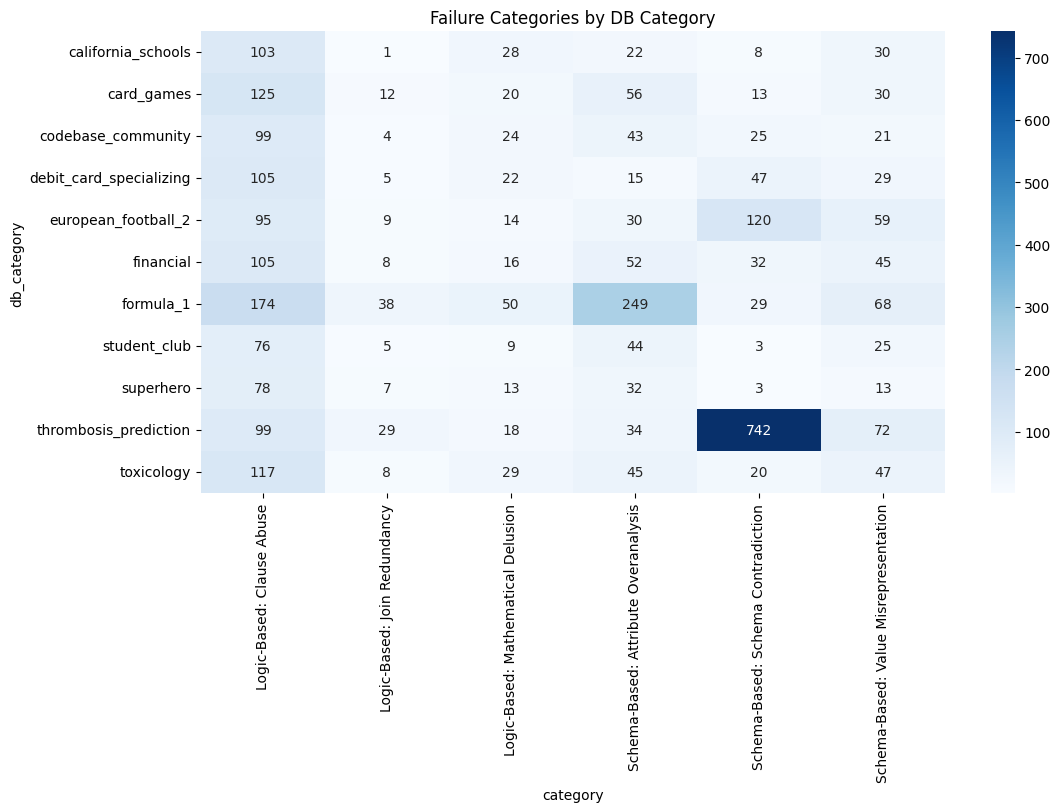

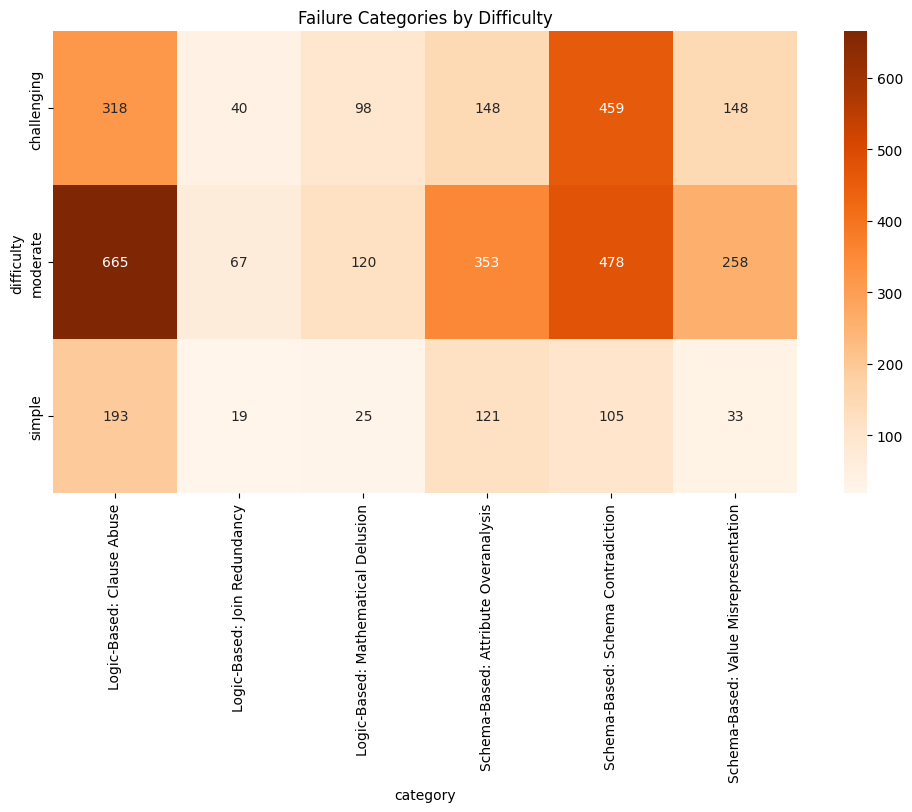

In [26]:
import re
import json
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

def extract_tables_columns(sql: str):
    """
    Extract table names and column names from a SQL query.
    """
    tables = set()
    columns = set()
    sql_lower = sql.lower()

    # Extract tables from FROM and JOIN clauses
    # Matches patterns like "FROM table_name" or "JOIN table_name"
    table_pattern = re.compile(r'\bfrom\s+([a-z0-9_]+)|\bjoin\s+([a-z0-9_]+)', re.IGNORECASE)
    for match in table_pattern.finditer(sql_lower):
        tbl = match.group(1) or match.group(2)  # Get whichever group matched
        if tbl:
            tables.add(tbl)

    # Extract columns used with table alias: alias.column
    # Matches patterns like "t1.column_name" or "users.id"
    col_pattern = re.compile(r'\b([a-z0-9_]+)\.([a-z0-9_]+)\b', re.IGNORECASE)
    for match in col_pattern.finditer(sql_lower):
        col = match.group(2)  # Get the column name (after the dot)
        columns.add(col)

    # Extract columns from SELECT clause without alias
    # Find everything between SELECT and FROM
    select_pattern = re.compile(r'select\s+(.*?)\s+from', re.IGNORECASE | re.DOTALL)
    select_match = select_pattern.search(sql_lower)
    if select_match:
        select_cols = select_match.group(1)
        # Split by comma to get individual column references
        for part in select_cols.split(','):
            part = part.strip()
            # Ignore columns with table alias (have '.') and wildcard '*'
            if '.' not in part and part != '*':
                # Skip known SQL functions to avoid false positives
                if re.match(r'^(extract|substring|substr|cast|date_trunc)\b', part):
                    continue
                # Take first token before space or '(' to get base column name
                col_name = re.split(r'\s|[(]', part)[0]
                col_name = col_name.rstrip('),;')  # Clean up trailing punctuation
                # Validate column name format and exclude SQL keywords
                if re.match(r'^[a-z_][a-z0-9_]*$', col_name) and \
                   col_name not in {
                       "distinct", "case", "when", "then", "else", "end",
                       "count", "sum", "avg", "min", "max"
                   }:
                    columns.add(col_name)

    return tables, columns


def get_snippet(pred_query, keyword):
    """
    Extract a snippet of text around a keyword for context in error reporting.
    """
    # Find up to 40 characters before and after the keyword
    match = re.search(rf".{{0,40}}{re.escape(keyword)}.{{0,40}}", pred_query, re.IGNORECASE)
    return match.group().strip() if match else keyword


def extract_aliases(sql):
    """
    Extract table aliases from SQL query.
    """
    alias_map = {}

    # Patterns for different alias formats:
    # 1. FROM table AS alias
    # 2. FROM table alias (implicit AS)
    # 3. JOIN table AS alias  
    # 4. JOIN table alias (implicit AS)
    patterns = [
        re.compile(r'\bfrom\s+([a-z_][a-z0-9_]*)\s+as\s+([a-z_][a-z0-9_]*)', re.IGNORECASE),
        re.compile(r'\bfrom\s+([a-z_][a-z0-9_]*)\s+([a-z_][a-z0-9_]*)', re.IGNORECASE),
        re.compile(r'\bjoin\s+([a-z_][a-z0-9_]*)\s+as\s+([a-z_][a-z0-9_]*)', re.IGNORECASE),
        re.compile(r'\bjoin\s+([a-z_][a-z0-9_]*)\s+([a-z_][a-z0-9_]*)', re.IGNORECASE),
    ]

    # Apply each pattern and build the alias mapping
    for pattern in patterns:
        for match in pattern.finditer(sql):
            table = match.group(1).lower()  # Actual table name
            alias = match.group(2).lower()  # Alias name
            alias_map[alias] = table

    return alias_map


def extract_columns_with_aliases(sql):
    """
    Extract all column references that use table aliases (alias.column format).
    """
    # Match patterns like "t1.column_name" or "users.id"
    pattern = re.compile(r'\b([a-z_][a-z0-9_]*)\.([a-z_][a-z0-9_]*)\b', re.IGNORECASE)
    return pattern.findall(sql)


def is_column_in_any_table(col, tables, schema):
    """
    Check if a column exists in any of the specified tables according to the schema.
    """
    for tbl in tables:
        if tbl in schema and col in schema[tbl]:
            return True
    return False


def extract_where_literals(sql):
    """Extracts all string literals used in WHERE clause."""
    match = re.search(r'\bWHERE\b(.+)', sql, flags=re.IGNORECASE)
    if not match:
        return set()
    return set(re.findall(r"'(.*?)'", match.group(1)))



def categorize_failure_with_schema(gt_query, pred_query, bird_schema, sql_error):
    """
    Categorize SQL query failures by comparing ground truth and predicted queries.
    """
    categories = []

    # Normalize queries to different cases for different types of analysis
    gt_query_l = gt_query.lower()
    pred_query_l = pred_query.lower()
    pred_upper = pred_query.upper()
    gt_upper = gt_query.upper()

    # Extract structural elements from both queries
    gt_tables, gt_columns = extract_tables_columns(gt_query_l)
    pred_tables, pred_columns = extract_tables_columns(pred_query_l)
            
    # ALIAS VALIDATION
    BUILTIN_NAMES = {
        "date", "time", "timestamp", "interval",
        "current_date", "current_time", "current_timestamp",
        "year", "month", "day", "extract", "substr",
        "now", "age", "cast", "coalesce"
    }
    # ------------------------------------------------------------
    # SCHEMA-BASED VALIDATIONS-----------------------------------
    # ------------------------------------------------------------
    # SCHEMA-BASED: SCHEMA CONTRADICTION
    # ------------------------------------------------------------
    # Detect use of backticks or wildcard "*" which may indicate schema issues
    if re.search(r"`.*?`", pred_query) or re.search(r"\.\*", pred_query):
        categories.append(("Schema-Based: Schema Contradiction", 
                           "Use of backticks or wildcard '*'", 
                           get_snippet(pred_query, "*")))
    # Check for unknown tables (tables not in the schema)
    for tbl in pred_tables:
        # Skip flagging single-character table names
        if tbl not in bird_schema and len(tbl) > 1:
            categories.append(("Schema-Based: Schema Contradiction", 
                               f"Unknown table '{tbl}'", 
                               get_snippet(pred_query, tbl)))
    # Check for unknown columns (columns not present in any of the used tables)
    for col in pred_columns:
        if not col.isdigit() and not is_column_in_any_table(col, pred_tables, bird_schema):
            categories.append(("Schema-Based: Schema Contradiction", 
                               f"Unknown column '{col}'", 
                               get_snippet(pred_query, col)))
    # Check for valid columns that are used without referencing the correct table
    for col in pred_columns:
        if not col.isdigit() and col not in gt_columns:
            found_in_schema = any(col in bird_schema[tbl] for tbl in bird_schema)
            found_in_query_tables = any(col in bird_schema[tbl] for tbl in pred_tables if tbl in bird_schema)
            if found_in_schema and not found_in_query_tables:
                categories.append(("Schema-Based: Schema Contradiction", 
                                   f"Column '{col}' used without referencing its table", 
                                   get_snippet(pred_query, col)))
    # Extract and validate table aliases and their column usage
    alias_map = extract_aliases(pred_query_l)
    cols_with_alias = extract_columns_with_aliases(pred_query_l)
    for alias, col in cols_with_alias:
        alias_l = alias.lower()
        # Resolve alias to actual table name
        table = alias_map.get(alias_l) or (alias_l if alias_l in bird_schema else None)
        if alias_l in BUILTIN_NAMES:
            continue  # Skip built-in names like 'date'
        # Check if alias maps to a known table
        if not table:
            categories.append(("Schema-Based: Schema Contradiction", 
                               f"Unknown alias '{alias}'", 
                               get_snippet(pred_query, alias)))
            continue
        # Check if resolved table exists in schema
        if table not in bird_schema:
            categories.append(("Schema-Based: Schema Contradiction", 
                               f"Unknown table '{table}' via alias '{alias}'", 
                               get_snippet(pred_query, alias)))
            continue
        # Check if column exists in the resolved table
        if col not in bird_schema[table]:
            categories.append(("Schema-Based: Schema Contradiction", 
                               f"Unknown column '{col}' in table '{table}'", 
                               get_snippet(pred_query, col)))

    # ------------------------------------------------------------
    # SCHEMA-BASED: ATTRIBUTE OVERANALYSIS
    # ------------------------------------------------------------
    # Detect overused columns and tables (present in prediction but not in ground truth)
    overused_columns = [
        col for col in pred_columns
        if col not in gt_columns
        and is_column_in_any_table(col, pred_tables, bird_schema)
        and not re.search(rf'\b{re.escape(col)}\b', gt_query, re.IGNORECASE)
    ]
    overused_tables = [tbl for tbl in pred_tables if tbl not in gt_tables and tbl in bird_schema]
    # Report overused schema elements
    for col in overused_columns:
        categories.append(("Schema-Based: Attribute Overanalysis", 
                           f"Extra column '{col}'", 
                           get_snippet(pred_query, col)))
    for tbl in overused_tables:
        categories.append(("Schema-Based: Attribute Overanalysis", 
                           f"Extra table '{tbl}'", 
                           get_snippet(pred_query, tbl)))

    # ------------------------------------------------------------
    # SCHEMA-BASED: VALUE MISREPRESENTATION
    # ------------------------------------------------------------
    # Check for unnecessary type casting
    if re.search(r"::\w+", pred_query) and not re.search(r"::\w+", gt_query):
        cast_type = re.search(r"::\w+", pred_query).group()
        categories.append(("Schema-Based: Value Misrepresentation", 
                           f"Unnecessary cast {cast_type}", 
                           get_snippet(pred_query, cast_type)))
    gt_literals = extract_where_literals(gt_query)
    pred_literals = extract_where_literals(pred_query)
    # Ignore if either is empty or identical
    if gt_literals and gt_literals != pred_literals:
        differing_literals = gt_literals.symmetric_difference(pred_literals)
        for val in differing_literals:
            categories.append((
                "Schema-Based: Value Misrepresentation",
                f"Value mismatch in WHERE clause: literal '{val}' differs from GT",
                get_snippet(pred_query, val)))
    # Find fields that are casted in ground truth but not in prediction
    # Look for PostgreSQL-style casting (::) and CAST() function
    casted_fields = re.findall(r'([a-z0-9_]+\.[a-z0-9_]+)\s*::\s*\w+', 
                               gt_query_l, 
                               re.IGNORECASE)
    casted_fields += re.findall(r'CAST\(\s*([a-z0-9_]+\.[a-z0-9_]+)\s+AS\s+\w+\)', 
                                gt_query_l, 
                                re.IGNORECASE)
    for full_field in casted_fields:
        base_field = full_field.split(".")[-1]  # Get column name without table prefix
        field_used = re.search(rf'\b{base_field}\b', pred_query_l, re.IGNORECASE)
        # Check if the field is used in prediction but without casting
        casted_in_pred = re.search(rf'{re.escape(base_field)}\s*::\s*\w+', pred_query_l) or \
                         re.search(rf'CAST\s*\(\s*\b{base_field}\b\s+AS\s+\w+', pred_query_l)
        if field_used and not casted_in_pred:
            categories.append(("Schema-Based: Value Misrepresentation", 
                               f"Missing cast for field '{base_field}' (used in GT with cast)", 
                               get_snippet(pred_query, base_field)))

    # ------------------------------------------------------------
    # LOGIC-BASED VALIDATIONS-----------------------------------
    # ------------------------------------------------------------
    # LOGIC-BASED: CLAUSE ABUSE
    # ------------------------------------------------------------
    clause_keywords = [
        # Top-level clauses
        "SELECT", "FROM", "WHERE", "GROUP BY", "HAVING", "ORDER BY", "LIMIT", "OFFSET", "FETCH",
        "DISTINCT", "DISTINCT ON",
        # Joins
        "JOIN", "INNER JOIN", "LEFT JOIN", "RIGHT JOIN", "FULL JOIN", "CROSS JOIN", "NATURAL JOIN", "ON", "USING",
        # Set operations
        "UNION", "UNION ALL", "INTERSECT", "EXCEPT",
        # CTEs
        "WITH", "RECURSIVE", "MATERIALIZED", "NOT MATERIALIZED",
        # Windows
        "OVER", "PARTITION BY", "ROWS", "RANGE", "GROUPS", "WINDOW", "FILTER",
        # Aggregation / insert-modifiers
        "RETURNING", "ON CONFLICT",
        # Logical constructs that affect structure
        "CASE", "WHEN", "THEN", "ELSE", "END",
        "IS DISTINCT FROM", "IS NOT DISTINCT FROM",
        # Rare or vendor-specific
        "TABLESAMPLE", "LATERAL", "CROSS APPLY", "OUTER APPLY"
    ]
    for clause_kw in clause_keywords:
        if clause_kw in pred_upper and clause_kw not in gt_upper:
            categories.append(("Logic-Based: Clause Abuse", 
                               f"Unexpected clause '{clause_kw}'", 
                               get_snippet(pred_query, clause_kw)))
    # Check for unexpected logical operators
    if " OR " in pred_upper and " OR " not in gt_upper:
        categories.append(("Logic-Based: Clause Abuse", 
                           "Unexpected OR logic", 
                           get_snippet(pred_query, "OR")))
    if " AND " in pred_upper and " AND " not in gt_upper and "WHERE" in gt_upper:
        categories.append(("Logic-Based: Clause Abuse", 
                           "Unexpected AND logic with WHERE", 
                           get_snippet(pred_query, "AND")))

    # ------------------------------------------------------------
    # LOGIC-BASED: MATHEMATICAL DELUSION
    # ------------------------------------------------------------
    # Integer division check — only flag if present in pred but not gt, and lacks CAST or float indicator
    if "/" in pred_upper and "/" not in gt_upper:
        if "CAST" not in pred_upper and "1.0" not in pred_upper and ".0" not in pred_upper:
            categories.append((
                "Logic-Based: Mathematical Delusion",
                "Integer division without casting (missing CAST or float)",
                get_snippet(pred_query, "/")
            ))
    # Percentage check — flag if % is used in pred but not in gt, and lacks scaling
    if "%" in pred_upper and "%" not in gt_upper:
        if "* 100" not in pred_upper and "*100" not in pred_upper:
            categories.append((
                "Logic-Based: Mathematical Delusion",
                "Modulo used as percentage without scaling",
                get_snippet(pred_query, "%")
            ))
    # BETWEEN logic — flag if pred uses BETWEEN but ground truth does not, and no EXTRACT(YEAR)
    if "BETWEEN" in pred_upper and "BETWEEN" not in gt_upper:
        if "EXTRACT(YEAR" not in pred_upper and "DATE" not in pred_upper:
            categories.append((
                "Logic-Based: Mathematical Delusion",
                "BETWEEN used without proper date or range context",
                get_snippet(pred_query, "BETWEEN")
            ))      
    try:
        if "syntax error" in sql_error:
            match = re.search(r"syntax error.*?near\s+\"([^\"]+)\"", sql_error, re.IGNORECASE)
            token = match.group(1) if match else "unknown"
            snippet = get_snippet(pred_query, token)
            categories.append((
                "Logic-Based: Mathematical Delusion",
                f"Missing or invalid operator or structure near '{token}'",
                snippet
            ))
    except:
        pass

    # ------------------------------------------------------------
    # LOGIC-BASED: JOIN REDUNDANCY
    # ------------------------------------------------------------
    # Check for excessive JOINs compared to ground truth
    pred_join_count = len(re.findall(r"\bJOIN\b", pred_upper))
    gt_join_count = len(re.findall(r"\bJOIN\b", gt_upper))
    if pred_join_count > gt_join_count:
        categories.append(("Logic-Based: Join Redundancy", 
                           f"{pred_join_count - gt_join_count} extra JOIN(s)", 
                           get_snippet(pred_query, "JOIN")))
    
    # DEDUPLICATION
    # Remove duplicate categories based on category type and description
    seen = set()
    unique_categories = []
    for cat in categories:
        key = (cat[0], cat[1])  # Use category and description as key
        if key not in seen:
            seen.add(key)
            unique_categories.append(cat)

    return unique_categories


# MAIN EXECUTION BLOCK
if __name__ == "__main__":
    # Load evaluation data from JSON file
    with open('../mini_dev/evaluation/path_eval_log_paper_path_3_5_claude_history.json', 'r') as f:
        data = json.load(f)

    results = []
    
    # Initialize category counters for metrics
    category_counts = {}
    subcategory_counts = {}
    total_queries_analyzed = 0

    # Process each entry in the evaluation data
    for d in data:
        for i, entry in enumerate(d["path"]):
            gt_query = entry.get("gt_query", "")
            pred_query = entry.get("predicted_query", "")
            error = entry.get("error", "")
            # Only analyze incorrect predictions (correct=0 or None)
            if entry.get("correct") in [0, None]:
                total_queries_analyzed += 1
                categories = categorize_failure_with_schema(gt_query, pred_query, bird_schema, error)
                results.append({
                    "question_id": entry.get("question_id"),
                    "db_id": entry.get("db_id"),
                    "difficulty": entry.get("difficulty"),
                    "error": entry.get("error"),
                    "gt_query": gt_query,
                    "pred_query": pred_query,
                    "categories": categories,
                })
                d["path"][i]["hallucination"] = categories
                
                # Count only one occurrence per main category per query
                seen_main_categories = set()
                
                for cat, desc, snippet in categories:
                    if cat not in seen_main_categories:
                        category_counts[cat] = category_counts.get(cat, 0) + 1
                        seen_main_categories.add(cat)
                    
                    # Still count all subcategories (fine-grained metrics)
                    subcategory_counts[desc] = subcategory_counts.get(desc, 0) + 1


    
    # Load evaluation data from JSON file
    with open('../mini_dev/evaluation/path_eval_log_paper_path_hallu_3_5_claude_history.json', 'w+') as f:
        json.dump(data,f,indent=4)
    
    # # Output results with formatted display
    # for res in results:
    #     print(f"Question ID: {res['question_id']} (DB: {res['db_id']}, Difficulty: {res['difficulty']})")
    #     if res["error"]:
    #         print(f"  SQL Error: {res['error']}")
    #     print("  Ground Truth Query:")
    #     print(f"    {res['gt_query']}")
    #     print("  Predicted Query:")
    #     print(f"    {res['pred_query']}")
    #     print("  Detected Failure Categories:")
    #     # Display each category with bold formatting and code snippet
    #     for cat, desc, snippet in res["categories"]:
    #         print(f"  - \033[1m{cat}\033[0m: {desc}\n      → Snippet: `{snippet}`")
    #     print("\n---\n")

    
    # Collect tuples (category, db_category, difficulty)
    category_difficulty_db = []
    
    for res in results:
        db_cat = res.get("db_id", "unknown")  # You may need to attach this earlier
        difficulty = res.get("difficulty", "unknown")
        for cat, desc, snippet in res["categories"]:
            category_difficulty_db.append((cat, db_cat, difficulty))
    
    # Convert to DataFrame for analysis
    df_corr = pd.DataFrame(category_difficulty_db, columns=["category", "db_category", "difficulty"])


    # DB category vs. failure category
    plt.figure(figsize=(12, 6))
    sns.heatmap(df_corr.groupby(["db_category", "category"]).size().unstack(fill_value=0), annot=True, fmt="d", cmap="Blues")
    plt.title("Failure Categories by DB Category")
    plt.show()
    
    # Difficulty vs. failure category
    plt.figure(figsize=(12, 6))
    sns.heatmap(df_corr.groupby(["difficulty", "category"]).size().unstack(fill_value=0), annot=True, fmt="d", cmap="Oranges")
    plt.title("Failure Categories by Difficulty")
    plt.show()
